In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf

In [ ]:
@tf.function
def real_cal(r, phi):
    return r * tf.math.cos(phi)

@tf.function
def imag_cal(r, phi):
    return r * tf.math.sin(phi)

@tf.function
def oscillator_loop(X_r, X_i, omegas, num_steps):

    r_arr = tf.TensorArray(dtype=tf.float32, size=0, dynamic_size=True)
    phi_arr = tf.TensorArray(dtype=tf.float32, size=0, dynamic_size=True)
    r_t = tf.ones((X_r.shape[0], X_r.shape[-1]))
    phis = tf.zeros((X_r.shape[0], X_r.shape[-1]))
    dt = 0.001
    input_scaler = 5
    beta1 = 10
    for t in tf.range(num_steps):
        input_r = input_scaler*X_r[:,t,:]*tf.math.cos(phis)
        input_phi = input_scaler*X_i[:,t,:]*tf.math.sin(phis)
        r_t = r_t + ((1 - beta1*tf.square(r_t)) * r_t + input_r) * dt
        phis = phis + (omegas - input_phi) * dt
        r_arr = r_arr.write(r_arr.size(), r_t)
        phi_arr = phi_arr.write(phi_arr.size(), phis)
    r_arr = tf.transpose(r_arr.stack(), [1, 0, 2])
    phi_arr = tf.transpose(phi_arr.stack(), [1, 0, 2])
    return r_arr, phi_arr

class Hopf(tf.keras.layers.Layer):

    def __init__(self, units, num_steps, min_omega=0.1,
                 max_omega=10.1, **kwargs):
        super(Hopf, self).__init__(**kwargs)
        self.units = units
        self.num_steps = num_steps
        omegas = tf.linspace(min_omega, max_omega, self.units) * (2*3.1415)
        omegas = tf.cast(tf.expand_dims(omegas, 0), 'float32')
        self.omega_param = tf.Variable(omegas)

    def call(self, X_r, X_i):
        r, phi = oscillator_loop(X_r, X_i, self.omega_param, self.num_steps)
        z_real = real_cal(r, phi)
        z_imag = imag_cal(r, phi)
        return z_real, z_imag

In [ ]:
# @title
def generate_signals(num_samples=16, time_steps=1000,
					 num_components=1, min_omega=1,
					 max_omega=10, phase_delay=False,
					 c=0):

    t = np.arange(0, 1, 0.001)
    X = []
    Y = []
    for _ in range(num_samples):
        signal = np.zeros(time_steps)
        d_signal = np.zeros(time_steps)
        for _ in range(num_components):
            omega = np.random.uniform(min_omega, max_omega, 1)
            init_phase = 0
            if phase_delay:
                init_phase = np.random.randn()*2*np.pi
            signal += np.sin((2*np.pi)*(omega)*t + init_phase)
            d_signal += np.sin((2*np.pi)*(omega+c)*t + init_phase)
        X.append(signal)
        Y.append(d_signal)
    X = np.stack(X)
    Y = np.stack(Y)
    return np.expand_dims(X, -1), np.expand_dims(Y, -1)

In [ ]:
a, b = generate_signals(num_samples=200, num_components=5,
                        c=0, min_omega=10, max_omega=11,
                        phase_delay=True)
print(a.shape, b.shape)

(200, 1000, 1) (200, 1000, 1)


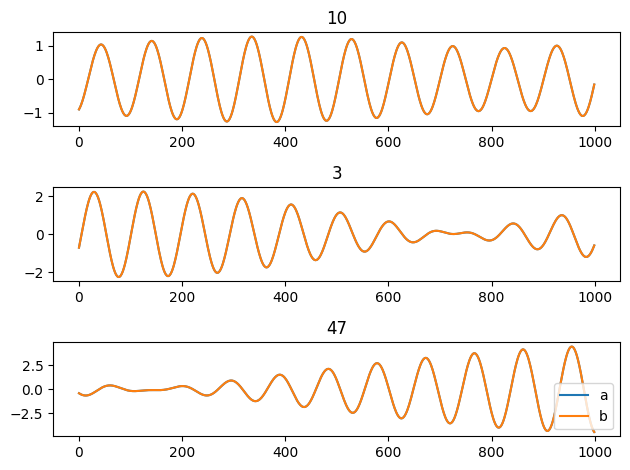

In [ ]:
fig, axs = plt.subplots(3)
for i in range(3):
    tt = np.random.randint(0, 50)
    axs[i].plot(a[tt].reshape(-1), label='a')
    axs[i].plot(b[tt].reshape(-1), label='b')
    axs[i].set_title(str(tt))
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
duration = 1_000

class Model(tf.keras.Model):

    def __init__(self, units, num_layers=1, osc_range=[[5, 7]], **kwargs):

        super(Model, self).__init__(**kwargs)

        self.id_r = tf.keras.layers.Dense(units,activation='relu', use_bias=True)
        self.id_i = tf.keras.layers.Dense(units,activation='relu', use_bias=True)
        self.osc_layers = []
        self.dr_layers = []
        self.di_layers = []
        self.num_layers = num_layers
        for il in  range(num_layers):
            min_omg = osc_range[il][0]
            max_omg = osc_range[il][1]
            self.osc_layers.append(Hopf(units, num_steps=duration, min_omega=min_omg,
                                        max_omega=max_omg))
            self.dr_layers.append(tf.keras.layers.Dense(units, activation='relu',
                                                        use_bias=True))
            self.di_layers.append(tf.keras.layers.Dense(units, activation='relu',
                                                        use_bias=True))
        self.tanh_d = tf.keras.layers.Dense(units, activation='tanh', use_bias=True)
        self.out_dense = tf.keras.layers.Dense(1, use_bias=True)

    def build(self, input_shape):
        self.built = True

    def call(self, X):

        z_r = tf.keras.layers.TimeDistributed(self.id_r)(X)
        z_i = tf.keras.layers.TimeDistributed(self.id_i)(X)

        for il in range(self.num_layers):
            z_rosc, z_iosc = self.osc_layers[il](z_r, z_i)
            z_r = tf.keras.layers.TimeDistributed(self.dr_layers[il])(z_rosc)
            z_i = tf.keras.layers.TimeDistributed(self.di_layers[il])(z_iosc)

        concat_inp = tf.concat([z_r, z_i], 2)
        out_tanh = tf.keras.layers.TimeDistributed(self.tanh_d)(concat_inp)
        out_final = tf.keras.layers.TimeDistributed(self.out_dense)(out_tanh)
        return out_final

model = Model(50, 1, [[0.1, 25]])
optimizer = tf.keras.optimizers.Adam(0.01)

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
                                    filepath='freq_adapter/model.weights.h5',
                                    save_weights_only=True,
                                    save_best_only = True)
model.compile(optimizer, 'mse')

In [ ]:
monitor = model.fit(a, a, epochs=50, batch_size=20, verbose=1)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 139s 8s/step - loss: 2.6713
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 77s 8s/step - loss: 1.5165
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 82s 8s/step - loss: 0.5939
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 82s 8s/step - loss: 0.3640
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 78s 8s/step - loss: 0.2490
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 81s 8s/step - loss: 0.1957
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 76s 8s/step - loss: 0.1667
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 83s 8s/step - loss: 0.1319
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 76s 8s/step - loss: 0.1075
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 82s 8s/step - loss: 0.0914
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 77s 8s/step - loss: 0.0947
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 81s 8s/step - loss: 0.0846
Epoch 13/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 76s 8s/step - loss: 0.0781
Epoch 14/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 77s 8s/step - loss: 0.0669
Epoch 15/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 83s 8s/step - loss: 0.0546
Epoch 16/50
10/10 

1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step


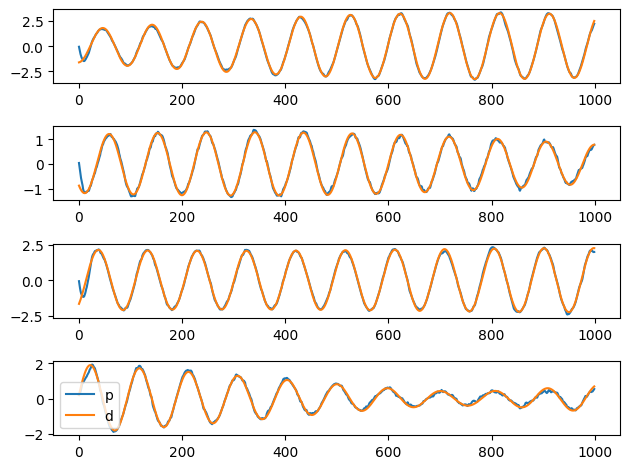

In [ ]:
fig, axs = plt.subplots(4, 1)
xx = np.random.randint(0, 50, 4)
pred_out = model.predict(a[xx], batch_size=4)
for i in range(4):
    axs[i].plot(pred_out[i], label='p')
    axs[i].plot(a[xx[i]], label='d')
plt.legend()
plt.tight_layout()

In [ ]:
dt = 0.001
t = np.arange(0, 1, dt)
t.shape

(1000,)

In [ ]:
model.weights

[<Variable path=model_1/time_distributed/dense_6/kernel, shape=(1, 50), dtype=float32, value=[[ 4.5528981e-01 -3.8135588e-02  1.0457829e-02 -5.6766573e-02
   -2.3312891e-01 -2.8883150e-01 -4.0863329e-03  6.7333627e-01
   -6.2166059e-01  3.2351246e-01 -1.3178446e-02  7.1005702e-01
    7.3340654e-01  5.9692740e-01 -8.2091081e-01  7.7539764e-04
    4.2494321e-01  3.8780800e-01 -3.1422663e-01  2.4377938e-01
   -1.9680937e-01 -2.5701979e-01 -2.2694948e-01  3.5739192e-01
   -3.4821850e-01 -4.7613728e-01 -4.6468198e-01  9.6593767e-01
    8.8451183e-01  9.1626471e-01 -6.5368962e-01  2.8835647e-02
   -5.5403727e-01 -1.0420686e+00  9.2871344e-01  5.5589741e-03
   -8.3995652e-01 -2.7237192e-02 -7.8843236e-01  1.6015600e-01
    6.3477576e-01 -5.8458072e-01  4.9590409e-01 -4.3543383e-02
    5.6285876e-01 -1.2396506e+00  7.7447504e-01  1.1919782e+00
   -1.3496799e+00 -1.7165488e-02]]>,
 <Variable path=model_1/time_distributed/dense_6/bias, shape=(50,), dtype=float32, value=[ 5.30665100e-04  7.305907